In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('../data/amazon_cleaned.csv')

# Business Questions Answered
- Which product categories generate the highest revenue?
- Which states and cities contribute most to total sales?



In [7]:
df['Category'].value_counts()

Category
Set              47031
kurta            46700
Western Dress    14703
Top              10163
Ethnic Dress      1093
Blouse             881
Bottom             420
Saree              155
Dupatta              3
Name: count, dtype: int64

In [8]:
df.head(3)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,B09KXVBD7Z,Shipped,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True


In [9]:
df['ship-city'].value_counts()

ship-city
BENGALURU                    10685
HYDERABAD                     7606
MUMBAI                        5867
NEW DELHI                     5450
CHENNAI                       5130
                             ...  
Vaishali Nagar Nagpur            1
VARANASIVaranasi                 1
GULABPURA, Distt BHILWARA        1
Prayagraj (ALLAHABAD)            1
Halol                            1
Name: count, Length: 8704, dtype: int64

In [10]:
df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

Category
Set              39195176.03
kurta            21291538.70
Western Dress    11215337.69
Top               5346812.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64

In [11]:
df.groupby('Category')['Amount'].mean().sort_values(ascending=False)

Category
Set              833.390233
Saree            799.572645
Western Dress    762.792470
Ethnic Dress     723.895389
Top              526.105707
Blouse           520.327106
kurta            455.921600
Bottom           358.733286
Dupatta          305.000000
Name: Amount, dtype: float64

<Axes: xlabel='Category', ylabel='count'>

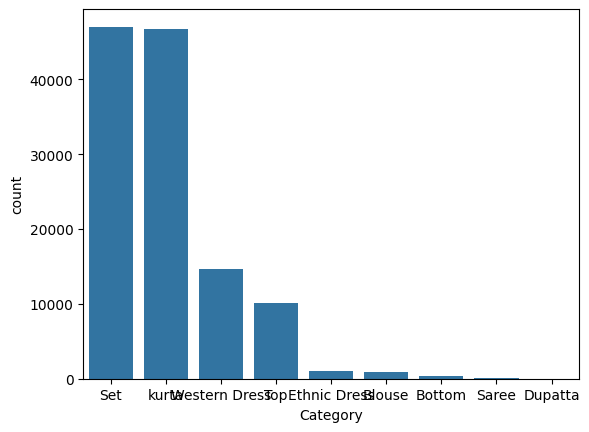

In [12]:
# Charts
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().index)

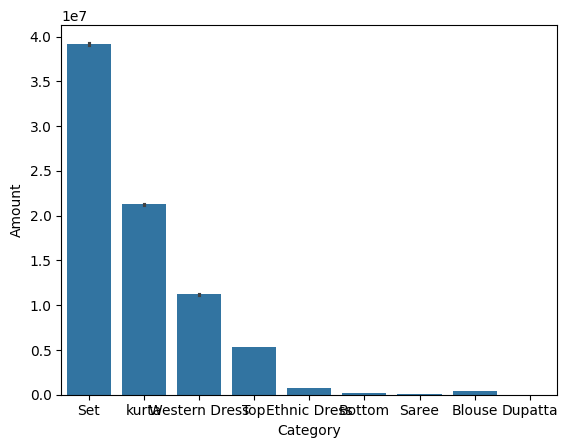

In [26]:
sns.barplot(data=df, x='Category', y='Amount', estimator=sum)
plt.savefig('images')

       - Regional Analysis -
Q: Which state brings the highest revenue?  
Q: Which city places the most orders?  
Q: Top 10 cities by order volume?

In [14]:
df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

ship-state
MAHARASHTRA       13335534.14
KARNATAKA         10481114.37
TELANGANA          6916615.65
UTTAR PRADESH      6816642.08
TAMIL NADU         6515650.11
DELHI              4235215.97
KERALA             3830227.58
WEST BENGAL        3507880.44
ANDHRA PRADESH     3219831.72
HARYANA            2882092.99
Name: Amount, dtype: float64

ANS: MAHARASHTRA Brings highest revenue here

Q: Top 10 cities by order volume?

In [15]:
df['ship-city'].value_counts().head(10)

ship-city
BENGALURU    10685
HYDERABAD     7606
MUMBAI        5867
NEW DELHI     5450
CHENNAI       5130
PUNE          3657
KOLKATA       2245
GURUGRAM      1783
THANE         1607
LUCKNOW       1354
Name: count, dtype: int64

 ANS: BANGLURU places highest amount of orders in india

In [22]:
# Chart
# Define top_states first
top_states = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10).reset_index()

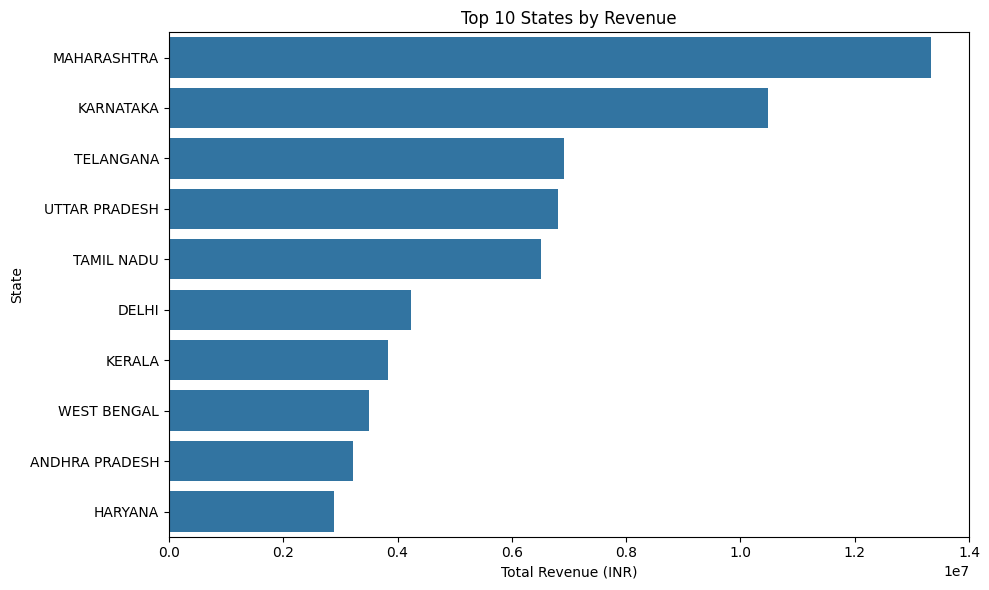

<Figure size 640x480 with 0 Axes>

In [25]:
# Then plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Amount', y='ship-state', data=top_states)
plt.title('Top 10 States by Revenue')
plt.xlabel('Total Revenue (INR)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('../images/statewise_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
plt.savefig('Images')

      -Amount Distribution- 
Q: How is sale amount distributed?                                                                  
Q: Are there outliers in pricing?

In [27]:
df['Amount'].describe()
df['Amount'].skew()       



np.float64(0.8854054151913563)

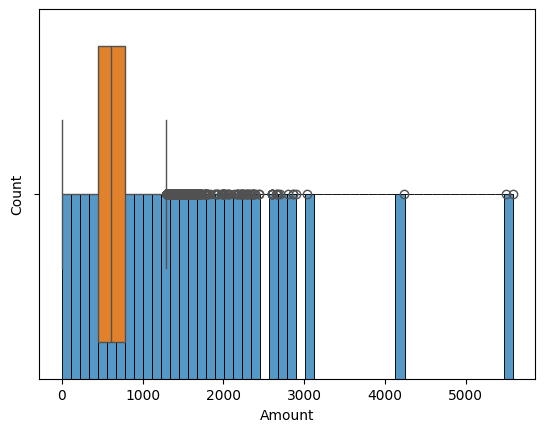

In [29]:
# Charts
sns.histplot(df['Amount'], bins=50)
sns.boxplot(x=df['Amount'])
plt.savefig('images')